In [3]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", message=".*encountered in matmul.*", category=RuntimeWarning)

from core import make_data, loss, optimal
from opt import gd, sgd, hf, cost_to_eps, acc_at_budget

%matplotlib inline

In [4]:
N, d   = 100, 20
kappas = np.logspace(0, 4, 9)
noises = [0.0, 0.1]

run_budget = 100_000
cost_val   = [1e2, 1e4]
eps_val    = [1e-2, 1e-6]
cg_tol     = 1e-8

assert max(cost_val) <= run_budget

color = {"HF": "#2a78d6", "GD": "#eb6834", "SGD": "#1baf7a"}
dash  = {"HF": "solid", "GD": (0, (6, 2)), "SGD": (0, (1.5, 2.2))}
mark  = {"HF": "o", "GD": "s", "SGD": "D"}
zord  = {"HF": 4, "GD": 5, "SGD": 6}
order = ["HF", "GD", "SGD"]
ink, muted, grid_c, surface = "#1a1a19", "#6b6b68", "#e4e4e1", "#fcfcfb"

pd.set_option("display.max_rows", 100)

In [11]:
def eigen_range(X):
    ev = np.linalg.eigvalsh((X.T @ X) / X.shape[0])
    return ev[0], ev[-1]


def prep(noise, kappa):
    X, y, _ = make_data(N, d, kappa, noise=noise)
    _, L_star = optimal(X, y)
    L0 = loss(np.zeros(d), X, y)
    lmin, lmax = eigen_range(X)
    lmin_sgd = None if noise == 0.0 else lmin
    t0 = time.perf_counter()
    _, st = sgd(X, y, budget=1.0, eps_floor=0.0, L_star=L_star,
                lmax=lmax, lmin=lmin_sgd)
    return {"X": X, "y": y, "L0": L0, "L_star": L_star,
            "lr_gd": 2.0 / (lmin + lmax), "lr_sgd": st["lr"], "batch": st["batch"],
            "lmin_sgd": lmin_sgd, "tune_s": time.perf_counter() - t0}


def run_one(P, m, budget, eps_floor):
    t0 = time.perf_counter()
    if m == "HF":
        _, st = hf(P["X"], P["y"], budget=budget, eps_floor=eps_floor,
                   L_star=P["L_star"], cg_tol=cg_tol)
    elif m == "GD":
        _, st = gd(P["X"], P["y"], P["lr_gd"], budget=budget, eps_floor=eps_floor,
                   L_star=P["L_star"])
    else:
        _, st = sgd(P["X"], P["y"], lr=P["lr_sgd"], batch=P["batch"], budget=budget,
                    eps_floor=eps_floor, L_star=P["L_star"], lmin=P["lmin_sgd"])
    st["seconds"] = time.perf_counter() - t0
    st["L0"], st["L_star"] = P["L0"], P["L_star"]
    return st


def readout(kind, st, lv):
    if kind == "cap":
        return max(acc_at_budget(st["trace"], st["L0"], st["L_star"], lv), 0.0), False
    c = cost_to_eps(st["trace"], st["L0"], st["L_star"], lv)
    return (run_budget if c is None else c), (c is None)


def style(ax, title, xlab=True, ylab=None, ylog=True):
    ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_facecolor(surface)
    ax.set_title(title, fontsize=10, color=ink, pad=6, loc="left")
    if xlab: ax.set_xlabel("κ", fontsize=9, color=muted)
    if ylab: ax.set_ylabel(ylab, fontsize=9, color=muted)
    ax.grid(True, which="major", color=grid_c, linewidth=0.8, zorder=0)
    ax.grid(True, which="minor", color=grid_c, linewidth=0.4, alpha=0.5, zorder=0)
    ax.tick_params(colors=muted, labelsize=8)
    for s in ax.spines.values(): s.set_color(grid_c)


def method_handles(censor=False):
    h = [plt.Line2D([], [], color=color[m], linewidth=2, linestyle=dash[m],
                    marker=mark[m], markersize=5, markeredgecolor=surface, label=lbl)
         for m, lbl in [("HF", "HF (Newton+CG)"), ("GD", "GD (full batch)"),
                        ("SGD", "SGD (batch=%d)" % BATCH)]]
    if censor:
        h.append(plt.Line2D([], [], color=muted, linestyle="none", marker="^",
                            markerfacecolor=surface, markeredgecolor=muted,
                            markersize=7, label="never reached (>= %s)" % f"{run_budget:,}"))
    return h


def block_table(kind, noise):
    levels = cost_val if kind == "cap" else eps_val
    lname  = "C" if kind == "cap" else "ε"
    idx, data = [], []
    for lv in levels:
        for k in kappas:
            rec = {}
            for m in order:
                st = runs[(kind, noise, k, m, lv)]
                v, cen = readout(kind, st, lv)
                if kind == "cap":
                    rec[m] = "<1e-16" if v < 1e-16 else f"{v:.2e}"
                else:
                    rec[m] = f"{v:,.0f}*" if cen else f"{v:,.0f}"
                rec[m + "_s"] = f"{st['seconds']:.3f}"
            idx.append((f"{lv:g}", f"{k:,.0f}"))
            data.append(rec)
    cols = [c for m in order for c in (m, m + "_s")]
    df = pd.DataFrame(data, index=pd.MultiIndex.from_tuples(idx, names=[lname, "kappa"]))
    return df[cols]


def _line(ax, ks, v, m, cen=None):
    z = zord[m]
    ax.plot(ks, v, color=color[m], linewidth=2, linestyle=dash[m], zorder=z)
    if cen is None:
        cen = np.zeros(len(ks), dtype=bool)
    ax.plot(ks[~cen], v[~cen], mark[m], color=color[m], markersize=5,
            markeredgecolor=surface, markeredgewidth=1.2, zorder=z + 0.5)
    if cen.any():
        ax.plot(ks[cen], v[cen], "^", color=surface, markersize=8,
                markeredgecolor=color[m], markeredgewidth=1.5, zorder=z + 0.5)


def plot_cap(noise):
    ks = np.asarray(kappas)
    fig, axes = plt.subplots(1, len(cost_val), figsize=(12, 4.6), sharey=True)
    fig.patch.set_facecolor(surface)
    for j, lv in enumerate(cost_val):
        ax = axes[j]
        for m in order:
            v = np.array([max(readout("cap", runs[("cap", noise, k, m, lv)], lv)[0], 1e-17)
                          for k in ks])
            _line(ax, ks, v, m)
        for e in eps_val:
            ax.axhline(e, color=muted, linewidth=0.8, linestyle=(0, (2, 3)), zorder=1)
        style(ax, f"C = {lv:,.0f}", ylab="Loss" if j == 0 else None)
    fig.legend(handles=method_handles(), loc="lower center", ncol=3, frameon=False, fontsize=9)
    fig.suptitle(f"Loss after cost reach C, noise = {noise}",
                 fontsize=13, color=ink, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0.09, 1, 0.92])
    plt.show()


def plot_tol(noise, metric):
    ks = np.asarray(kappas)
    ylab = "cost  (grad-equiv)" if metric == "cost" else "time  (s)"
    fig, axes = plt.subplots(1, len(eps_val), figsize=(12, 4.6), sharey=True)
    fig.patch.set_facecolor(surface)
    for j, lv in enumerate(eps_val):
        ax = axes[j]
        for m in order:
            sts = [runs[("tol", noise, k, m, lv)] for k in ks]
            cen = np.array([readout("tol", st, lv)[1] for st in sts], dtype=bool)
            v = np.array([readout("tol", st, lv)[0] if metric == "cost"
                          else max(st["seconds"], 1e-5) for st in sts])
            _line(ax, ks, v, m, cen)
        if metric == "cost":
            ax.axhline(run_budget, color=muted, linewidth=1, linestyle=(0, (4, 3)), zorder=1)
        style(ax, f"ε = $10^{{{round(np.log10(lv))}}}$", ylab=ylab if j == 0 else None)
    fig.legend(handles=method_handles(censor=True), loc="lower center",
               ncol=4, frameon=False, fontsize=9)
    fig.suptitle(f"{'Cost' if metric == 'Cost' else 'Time (s)'} to reach ε, noise = {noise}",
                 fontsize=13, color=ink, x=0.02, ha="left")
    fig.tight_layout(rect=[0, 0.09, 1, 0.92])
    plt.show()

In [12]:
runs = {}
t_all = time.perf_counter()

for noise in noises:
    for kappa in kappas:
        P = prep(noise, kappa)
        BATCH = P["batch"]
        line = f"noise={noise} k={kappa:>9.1f}  (sgd lr={P['lr_sgd']:.3g}, tune {P['tune_s']:.2f}s)"
        for m in order:
            for lv in cost_val:
                runs[("cap", noise, kappa, m, lv)] = run_one(P, m, lv, 0.0)
            for lv in eps_val:
                runs[("tol", noise, kappa, m, lv)] = run_one(P, m, run_budget, lv)
            tot = sum(runs[(kd, noise, kappa, m, lv)]["seconds"]
                      for kd, lvs in (("cap", cost_val), ("tol", eps_val)) for lv in lvs)
            line += f"  {m}={tot:.2f}s"
        print(line)

print(f"\n{len(runs)} runs, total {time.perf_counter() - t_all:.1f}s")

noise=0.0 k=      1.0  (sgd lr=0.25, tune 0.05s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=      3.2  (sgd lr=0.158, tune 0.02s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=     10.0  (sgd lr=0.1, tune 0.12s)  HF=0.00s  GD=0.00s  SGD=0.00s
noise=0.0 k=     31.6  (sgd lr=0.0316, tune 0.02s)  HF=0.00s  GD=0.01s  SGD=0.01s
noise=0.0 k=    100.0  (sgd lr=0.015, tune 0.04s)  HF=0.00s  GD=0.02s  SGD=0.03s
noise=0.0 k=    316.2  (sgd lr=0.00474, tune 0.09s)  HF=0.00s  GD=0.13s  SGD=0.06s
noise=0.0 k=   1000.0  (sgd lr=0.0015, tune 0.20s)  HF=0.00s  GD=0.18s  SGD=0.14s
noise=0.0 k=   3162.3  (sgd lr=0.000474, tune 0.33s)  HF=0.00s  GD=0.26s  SGD=0.42s
noise=0.0 k=  10000.0  (sgd lr=0.00015, tune 0.44s)  HF=0.00s  GD=0.57s  SGD=0.70s
noise=0.1 k=      1.0  (sgd lr=0.5, tune 0.02s)  HF=0.00s  GD=0.00s  SGD=0.71s
noise=0.1 k=      3.2  (sgd lr=0.316, tune 0.02s)  HF=0.00s  GD=0.00s  SGD=0.83s
noise=0.1 k=     10.0  (sgd lr=0.05, tune 0.03s)  HF=0.00s  GD=0.00s  SGD=0.80s
noise=0.1 k=     31.6  (s

# 1. Clean data — noise = 0

## 1a. Fixed cost limit


HF   HF_s        GD   GD_s       SGD  SGD_s
C     kappa                                                  
100   1       <1e-16  0.000    <1e-16  0.000    <1e-16  0.001
      3       <1e-16  0.000    <1e-16  0.001    <1e-16  0.001
      10      <1e-16  0.001    <1e-16  0.001    <1e-16  0.002
      32      <1e-16  0.001  3.25e-07  0.001    <1e-16  0.006
      100     <1e-16  0.001  2.61e-03  0.001  6.61e-16  0.007
      316     <1e-16  0.001  5.40e-02  0.001  7.04e-08  0.007
      1,000   <1e-16  0.001  1.64e-01  0.001  1.99e-05  0.006
      3,162   <1e-16  0.001  2.64e-01  0.001  1.22e-03  0.006
      10,000  <1e-16  0.001  3.42e-01  0.001  4.66e-03  0.006
10000 1       <1e-16  0.000    <1e-16  0.000    <1e-16  0.001
      3       <1e-16  0.000    <1e-16  0.001    <1e-16  0.001
      10      <1e-16  0.001    <1e-16  0.002    <1e-16  0.002
      32      <1e-16  0.001    <1e-16  0.006    <1e-16  0.006
      100     <1e-16  0.001    <1e-16  0.018    <1e-16  0.015
      316     <1e-16  0.001    <1e-16  0.113    <1e-16  0.044
      1,000   <1e-16  0.001    <1e-16  0.129    <1e-16  0.121
      3,162   <1e-16  0.001  9.45e-07  0.114    <1e-16  0.383
      10,000  <1e-16  0.001  6.43e-03  0.113    <1e-16  0.624

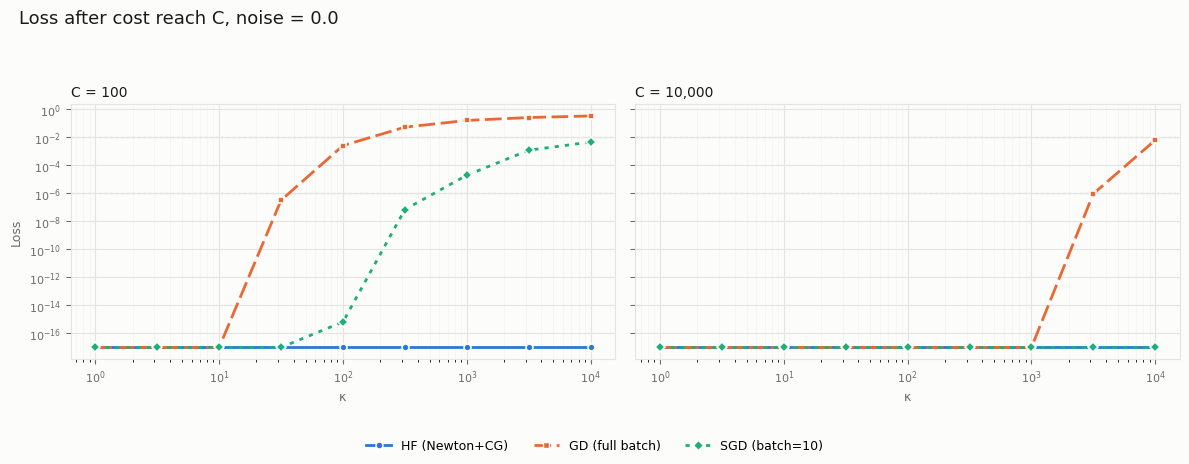

In [13]:
display(block_table("cap", noises[0]))
plot_cap(noises[0])

## 1b. Fixed error tolerance

HF   HF_s      GD   GD_s    SGD  SGD_s
ε     kappa                                         
0.01  1        2  0.000       1  0.000      2  0.000
      3        3  0.000       3  0.000      2  0.000
      10       5  0.000       6  0.000      2  0.000
      32       7  0.000      20  0.000      4  0.000
      100      8  0.000      67  0.002      5  0.001
      316      9  0.000     233  0.003      8  0.001
      1,000    9  0.000     795  0.009      9  0.001
      3,162    8  0.000   2,675  0.030      9  0.001
      10,000   8  0.001   8,897  0.100      9  0.001
1e-06 1        2  0.000       1  0.000      5  0.000
      3        7  0.000       9  0.000      5  0.000
      10      11  0.000      28  0.000      6  0.000
      32      15  0.000      92  0.001     14  0.001
      100     17  0.000     297  0.003     28  0.002
      316     19  0.000     961  0.011     71  0.004
      1,000   23  0.000   3,097  0.036    167  0.010
      3,162   26  0.000   9,956  0.111    423  0.027
      10,000  28  0.001  31,923  0.359  1,036  0.066

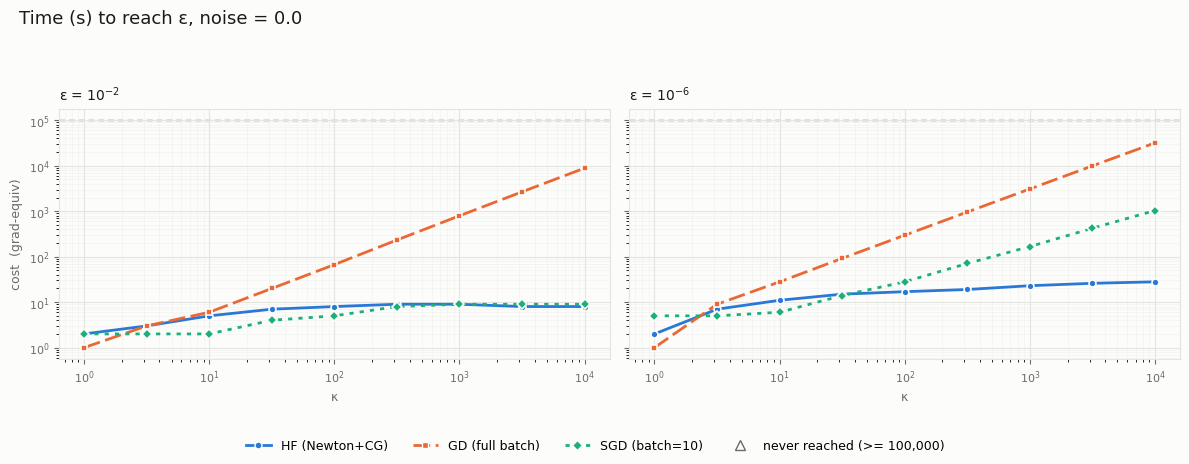

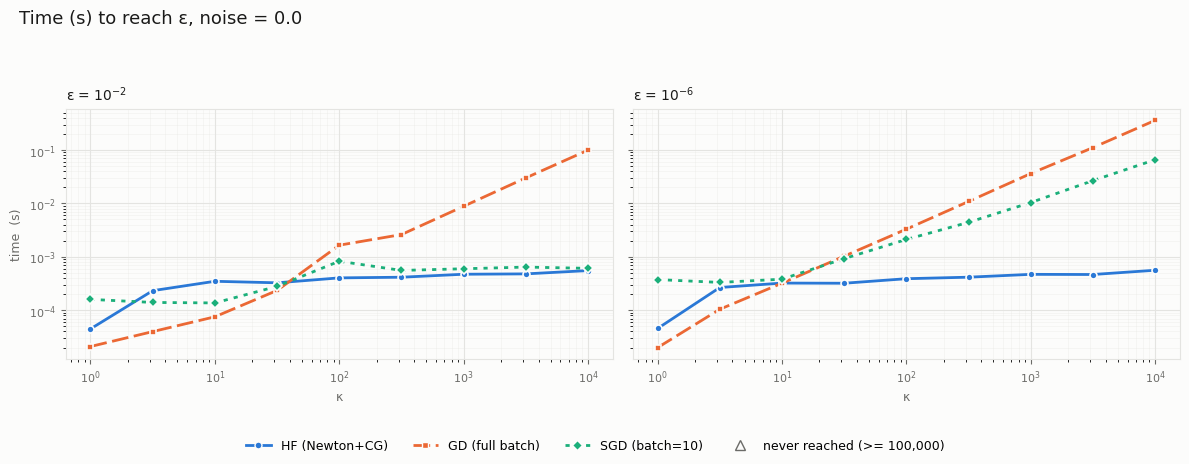

In [14]:
display(block_table("tol", noises[0]))
plot_tol(noises[0], "cost")
plot_tol(noises[0], "time")

# 2. Noisy data

$y = Xw_{\text{true}} + \sigma\,\mathrm{std}(y)\,\epsilon$.
where $\sigma = 0.1$ and $\epsilon$ is a $(n,)$ array drawn from $N(0,1)$

## 2a. Fixed cost limit

HF   HF_s        GD   GD_s       SGD  SGD_s
C     kappa                                                  
100   1       <1e-16  0.000    <1e-16  0.000  1.21e-05  0.007
      3       <1e-16  0.002    <1e-16  0.000  1.71e-05  0.006
      10      <1e-16  0.001    <1e-16  0.001  3.43e-05  0.006
      32      <1e-16  0.000  3.79e-07  0.001  7.27e-05  0.006
      100     <1e-16  0.001  2.97e-03  0.001  1.63e-04  0.006
      316     <1e-16  0.002  6.01e-02  0.001  4.23e-04  0.007
      1,000   <1e-16  0.002  1.79e-01  0.001  9.06e-04  0.006
      3,162   <1e-16  0.001  2.85e-01  0.001  3.52e-03  0.006
      10,000  <1e-16  0.001  3.65e-01  0.001  4.50e-03  0.006
10000 1       <1e-16  0.000    <1e-16  0.000  1.92e-07  0.666
      3       <1e-16  0.002    <1e-16  0.000  2.62e-07  0.660
      10      <1e-16  0.001    <1e-16  0.001  5.01e-07  0.639
      32      <1e-16  0.000    <1e-16  0.003  6.60e-07  0.631
      100     <1e-16  0.001    <1e-16  0.011  8.30e-07  0.655
      316     <1e-16  0.081    <1e-16  0.112  1.37e-06  0.620
      1,000   <1e-16  0.004    <1e-16  0.111  5.09e-06  0.618
      3,162   <1e-16  0.001  1.02e-06  0.112  2.90e-05  0.614
      10,000  <1e-16  0.001  6.88e-03  0.113  7.85e-05  0.619

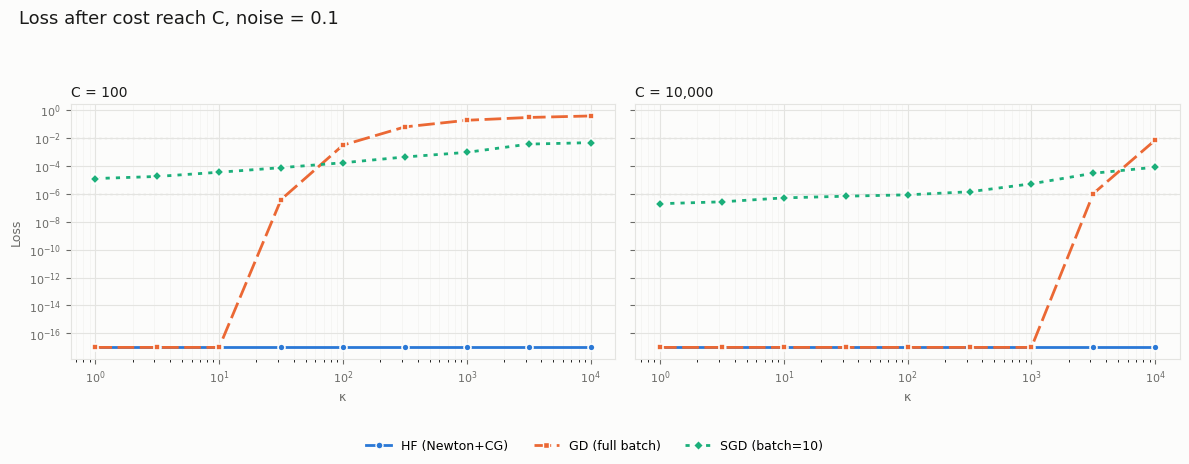

In [15]:
display(block_table("cap", noises[1]))
plot_cap(noises[1])

## 2b. Fixed error tolerance — stop at `eps`

HF   HF_s      GD   GD_s     SGD  SGD_s
ε     kappa                                          
0.01  1        2  0.000       1  0.000       2  0.000
      3        3  0.000       3  0.000       2  0.000
      10       5  0.000       7  0.000       3  0.000
      32       6  0.000      21  0.000       3  0.000
      100      8  0.000      70  0.001       5  0.000
      316      9  0.000     241  0.003       9  0.001
      1,000    9  0.000     818  0.009      12  0.001
      3,162    8  0.000   2,737  0.031      13  0.001
      10,000   8  0.001   9,065  0.103      12  0.001
1e-06 1        2  0.000       1  0.000     619  0.037
      3        7  0.000       9  0.000   2,594  0.166
      10      11  0.000      29  0.000   2,453  0.152
      32      15  0.000      93  0.001   2,451  0.152
      100     17  0.000     300  0.003   5,488  0.343
      316     19  0.000     969  0.010   6,345  0.423
      1,000   22  0.000   3,120  0.035  11,060  0.682
      3,162   24  0.000  10,018  0.112  24,850  1.541
      10,000  26  0.001  32,091  0.363  40,362  2.486

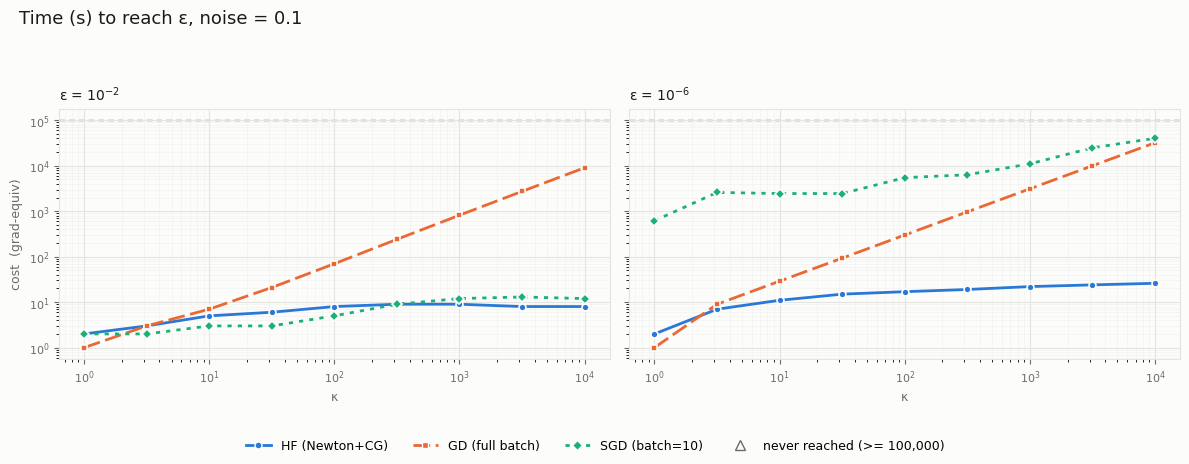

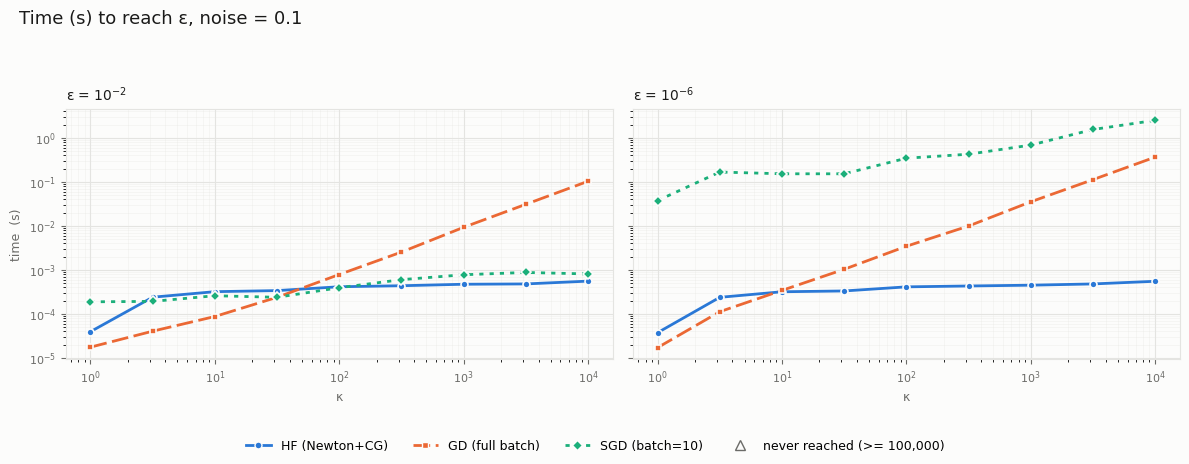

In [16]:
display(block_table("tol", noises[1]))
plot_tol(noises[1], "cost")
plot_tol(noises[1], "time")